# Team Basketball Analytics - PELISSANNE BASKET AVENIR

Analyse complète avec évolution des ratings Elo

In [1]:
# Importations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ffbb_api_client_v2 import FFBBAPIClientV2, TokenManager
from ffbb_api_client_v2.models.categorie_type import CategorieType
from ffbb_api_client_v2.models.competition_origine_type_competition import CompetitionOrigineTypeCompetition
from ffbb_api_client_v2.models.niveau_type import NiveauType as NiveauTypeEnum

# Configuration
plt.style.use('default')
sns.set_palette("husl")

TEAM_NAME = "PELISSANNE BASKET AVENIR"
COMPETITION_FILTERS = {
    "sexe": "M",
    "zone": NiveauTypeEnum.REGIONAL.value,
    "division": 2,
    "niveau_competition": CompetitionOrigineTypeCompetition.DIV.value,
    "categorie": CategorieType.SENIOR.value,
}

# Initialisation client
tokens = TokenManager.get_tokens()
client = FFBBAPIClientV2.create(
    meilisearch_bearer_token=tokens.meilisearch_token,
    api_bearer_token=tokens.api_token,
    debug=False,
)

print("✅ FFBB API Client initialized successfully!")

2026-02-09 18:22:11,837 - ApiFFBBAppClient - INFO - ApiFFBBAppClient initialized successfully


2026-02-09 18:22:11,838 - MeilisearchFFBBClient - INFO - MeilisearchClient initialized successfully


✅ FFBB API Client initialized successfully!


In [2]:
# Fonction pour trouver l'ID de poule
def find_team_poule_id(client, team_name, filters):
    search_results = client.search_organismes(name=team_name)
    if not search_results or not search_results.hits:
        raise ValueError(f"Team {team_name} not found")
    
    organisme_id = int(search_results.hits[0].id)
    organisme_response = client.get_organisme(organisme_id)
    
    for engagement in organisme_response.engagements:
        if not engagement.idCompetition:
            continue
        comp = engagement.idCompetition
        if (comp.sexe == filters["sexe"] and 
            comp.typeCompetition == filters["niveau_competition"]):
            if comp.niveau and comp.niveau.type.value == filters["zone"]:
                if engagement.idPoule:
                    return int(engagement.idPoule.id)
    
    raise ValueError(f"No poule found for {team_name}")

# Chargement des données
poule_id = find_team_poule_id(client, TEAM_NAME, COMPETITION_FILTERS)
poule_data = client.get_poule(poule_id)

# Conversion en DataFrame
rankings_data = []
for ranking in poule_data.classements:
    rankings_data.append({
        'position': ranking.position,
        'team_name': ranking.id_engagement.nom,
        'points': ranking.points,
        'wins': ranking.gagnes,
        'losses': ranking.perdus,
        'games_played': ranking.match_joues,
        'points_scored': ranking.paniers_marques,
        'points_allowed': ranking.paniers_encaisses,
        'point_diff': ranking.difference,
    })

rankings_df = pd.DataFrame(rankings_data)
rankings_df.set_index('position', inplace=True)
print(f"✅ Loaded championship data for {len(rankings_df)} teams")
rankings_df.head()

✅ Loaded championship data for 12 teams


,team_name,points,wins,losses,games_played,points_scored,points_allowed,point_diff
position,,,,,,,,
1,US CAGNES SUR MER,30,14,2,16,1313,964,349
10,LASA BC ASPTT,21,5,11,16,1033,1151,-118
11,ES VILLENEUVE LOUBET BASKET,18,2,14,16,1056,1348,-292
12,PELISSANNE BASKET AVENIR,17,1,15,16,973,1403,-430
2,UNION SPORTIVE AVIGNON/PONTET,28,13,2,15,1327,882,445


## 📊 Analyse PELISSANNE BASKET AVENIR

In [3]:
# Analyse de base
team_data = rankings_df[rankings_df['team_name'] == TEAM_NAME].iloc[0]

print(f"📊 Analysis for {TEAM_NAME}")
print(f"Position: {team_data.name}/{len(rankings_df)}")
print(f"Record: {team_data['wins']}-{team_data['losses']}")
print(f"Win %: {team_data['wins']/team_data['games_played']:.1%}")
print(f"Points/Game: {team_data['points_scored']/team_data['games_played']:.1f}")
print(f"Points Allowed/Game: {team_data['points_allowed']/team_data['games_played']:.1f}")
print(f"Point Differential: {team_data['point_diff']:+d}")

📊 Analysis for PELISSANNE BASKET AVENIR
Position: 12/12
Record: 1-15
Win %: 6.2%
Points/Game: 60.8
Points Allowed/Game: 87.7
Point Differential: -430


## 📈 Évolution des Ratings Elo

Système de rating qui évolue match par match pour toutes les équipes

In [4]:
# Système de rating Elo
def calculate_expected_score(rating_a, rating_b):
    """Calculate expected score for team A vs team B using Elo formula"""
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def calculate_rating_evolution(poule_data):
    """Calculate rating evolution for all teams throughout the season"""
    # Initialize ratings
    team_ratings = {}
    rating_history = {}
    
    for ranking in poule_data.classements:
        team_name = ranking.id_engagement.nom
        team_ratings[team_name] = 1500.0
        rating_history[team_name] = []
    
    # Get played matches and sort by date
    played_matches = [r for r in poule_data.rencontres if r.joue]
    played_matches.sort(key=lambda x: x.date_rencontre)
    
    K = 32  # K-factor
    
    for match_idx, match in enumerate(played_matches):
        team1 = match.nomEquipe1
        team2 = match.nomEquipe2
        
        if team1 not in team_ratings or team2 not in team_ratings:
            continue
        
        score1 = int(match.resultatEquipe1)
        score2 = int(match.resultatEquipe2)
        
        # Determine winner
        if score1 > score2:
            actual1, actual2 = 1, 0
        elif score1 < score2:
            actual1, actual2 = 0, 1
        else:
            actual1, actual2 = 0.5, 0.5
        
        rating1 = team_ratings[team1]
        rating2 = team_ratings[team2]
        
        expected1 = calculate_expected_score(rating1, rating2)
        expected2 = calculate_expected_score(rating2, rating1)
        
        # Update ratings
        new_rating1 = rating1 + K * (actual1 - expected1)
        new_rating2 = rating2 + K * (actual2 - expected2)
        
        team_ratings[team1] = new_rating1
        team_ratings[team2] = new_rating2
        
        # Record history
        for team in team_ratings:
            rating_history[team].append({
                'match': match_idx + 1,
                'date': match.date_rencontre,
                'rating': team_ratings[team],
                'change': 0
            })
    
    # Calculate changes
    for team in rating_history:
        for i in range(len(rating_history[team])):
            if i == 0:
                rating_history[team][i]['change'] = rating_history[team][i]['rating'] - 1500
            else:
                rating_history[team][i]['change'] = (
                    rating_history[team][i]['rating'] - rating_history[team][i-1]['rating']
                )
    
    return rating_history, team_ratings

# Calculate ratings
rating_history, final_ratings = calculate_rating_evolution(poule_data)
print(f"✅ Rating evolution calculated for {len(rating_history)} teams")
print(f"Matches processed: {len(next(iter(rating_history.values())))}")

✅ Rating evolution calculated for 12 teams
Matches processed: 65


In [5]:
# Convert to DataFrames
rating_dfs = {}
for team, history in rating_history.items():
    rating_dfs[team] = pd.DataFrame(history)

# Final ratings ranking with normalized ratings
final_rating_df = pd.DataFrame({
    'team_name': list(final_ratings.keys()),
    'final_rating': list(final_ratings.values())
}).sort_values('final_rating', ascending=False).reset_index(drop=True)

final_rating_df['rank'] = final_rating_df.index + 1
final_rating_df['rating_change'] = final_rating_df['final_rating'] - 1500
final_rating_df['normalized_rating'] = (final_rating_df['final_rating'] - final_rating_df['final_rating'].min()) / (final_rating_df['final_rating'].max() - final_rating_df['final_rating'].min())

print("🏆 Final Elo Rating Rankings")
print("=" * 40)
for _, row in final_rating_df.head(5).iterrows():
    change_symbol = "+" if row['rating_change'] >= 0 else ""
    print(f"{int(row['rank']):2d}. {row['team_name'][:20]:20} {row['final_rating']:6.1f} ({change_symbol}{row['rating_change']:5.1f}) | Norm: {row['normalized_rating']:.3f}")

print("...")

# Show target team
target_row = final_rating_df[final_rating_df['team_name'] == TEAM_NAME]
if not target_row.empty:
    row = target_row.iloc[0]
    change_symbol = "+" if row['rating_change'] >= 0 else ""
    print(f"{int(row['rank']):2d}. {row['team_name'][:20]:20} {row['final_rating']:6.1f} ({change_symbol}{row['rating_change']:5.1f}) | Norm: {row['normalized_rating']:.3f}")

🏆 Final Elo Rating Rankings
 1. ELAN BASKET PERNOIS  1647.0 (+147.0) | Norm: 1.000
 2. UNION SPORTIVE AVIGN 1644.1 (+144.1) | Norm: 0.990
 3. OLYMPIQUE CARROS BAS 1558.7 (+ 58.7) | Norm: 0.689
 4. ISTRES SPORTS BC     1541.7 (+ 41.7) | Norm: 0.629
 5. US CAGNES SUR MER    1500.0 (+  0.0) | Norm: 0.482
...
11. PELISSANNE BASKET AV 1370.2 (-129.8) | Norm: 0.025


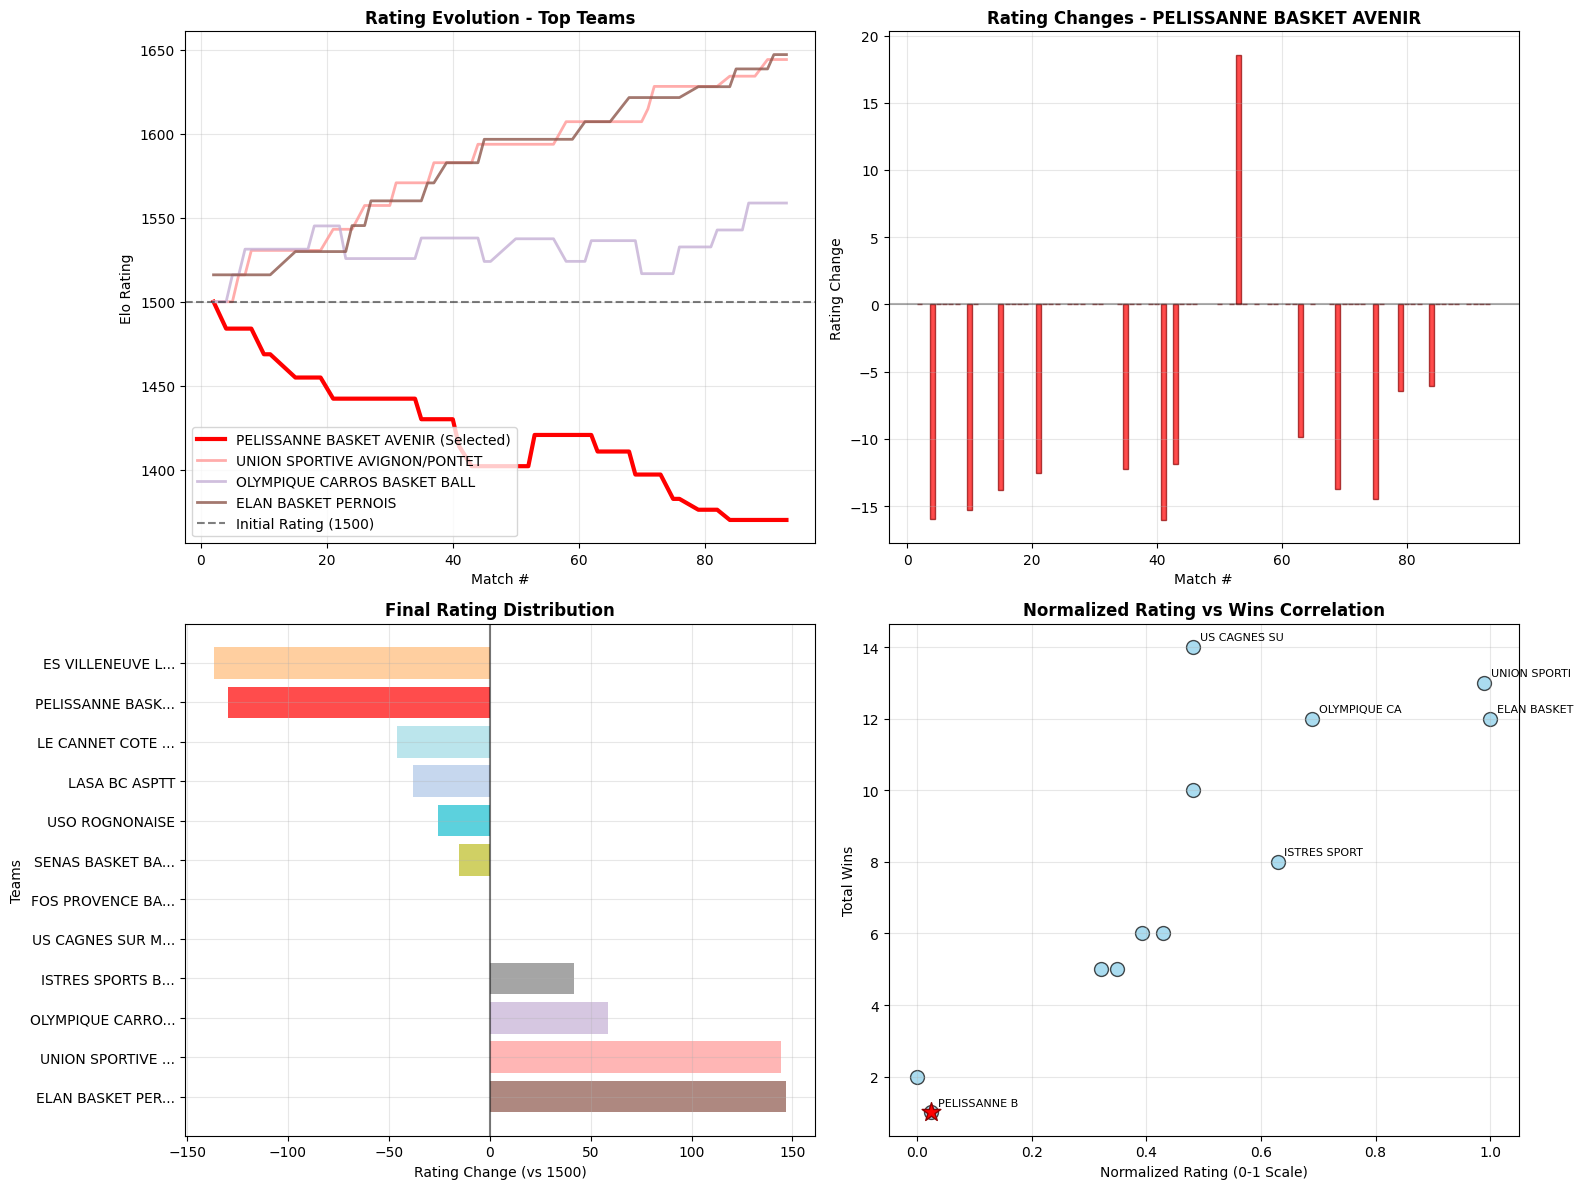


📊 Rating Analysis - PELISSANNE BASKET AVENIR
Initial Rating: 1500.0
Final Rating: 1370.2
Normalized Rating: 0.025 (0-1 scale)
Total Change: -129.8
Highest Rating: 1500.0
Lowest Rating: 1370.2
Average Change per Match: -2.00
Final Rating Rank: 11/12


In [6]:
# Rating Evolution Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Color mapping
team_colors = plt.cm.tab20(np.linspace(0, 1, len(rating_history)))
color_map = {team: team_colors[i] for i, team in enumerate(rating_history.keys())}
color_map[TEAM_NAME] = 'red'

# 1. Rating Evolution Over Season
for team, df in rating_dfs.items():
    if team == TEAM_NAME:
        ax1.plot(df['match'], df['rating'], '-', color=color_map[team], linewidth=3, alpha=1, label=f'{team} (Selected)')
    elif team in final_rating_df.head(3)['team_name'].values:
        ax1.plot(df['match'], df['rating'], '-', color=color_map[team], linewidth=2, alpha=0.8, label=team)

ax1.axhline(y=1500, color='black', linestyle='--', alpha=0.5, label='Initial Rating (1500)')
ax1.set_xlabel('Match #')
ax1.set_ylabel('Elo Rating')
ax1.set_title('Rating Evolution - Top Teams', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Rating Changes (Match by Match) - Target Team
if TEAM_NAME in rating_dfs:
    target_df = rating_dfs[TEAM_NAME]
    ax2.bar(target_df['match'], target_df['change'], color='red', alpha=0.7, edgecolor='darkred')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.set_xlabel('Match #')
    ax2.set_ylabel('Rating Change')
    ax2.set_title(f'Rating Changes - {TEAM_NAME}', fontweight='bold')
    ax2.grid(True, alpha=0.3)

# 3. Final Rating Distribution
final_ratings_list = [final_ratings[team] for team in final_rating_df['team_name']]
colors = [color_map.get(team, 'skyblue') for team in final_rating_df['team_name']]

bars = ax3.barh(range(len(final_rating_df)), final_rating_df['rating_change'], color=colors, alpha=0.7)
ax3.set_yticks(range(len(final_rating_df)))
ax3.set_yticklabels([name[:15] + '...' if len(name) > 15 else name for name in final_rating_df['team_name']])
ax3.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax3.set_xlabel('Rating Change (vs 1500)')
ax3.set_ylabel('Teams')
ax3.set_title('Final Rating Distribution', fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Rating vs Wins Correlation
correlation_data = []
for team in final_ratings:
    team_stats = rankings_df[rankings_df['team_name'] == team]
    if not team_stats.empty:
        team_norm_rating = final_rating_df[final_rating_df['team_name'] == team]['normalized_rating'].iloc[0]
        correlation_data.append({
            'team': team,
            'normalized_rating': team_norm_rating,
            'wins': team_stats['wins'].iloc[0]
        })

corr_df = pd.DataFrame(correlation_data)
scatter = ax4.scatter(corr_df['normalized_rating'], corr_df['wins'], s=100, c='skyblue', alpha=0.7, edgecolors='black')

# Highlight target team
target_corr = corr_df[corr_df['team'] == TEAM_NAME]
if not target_corr.empty:
    ax4.scatter(target_corr['normalized_rating'], target_corr['wins'], s=200, c='red', marker='*', edgecolors='darkred')

# Add team labels for top teams
top_teams = final_rating_df.head(5)['team_name'].tolist() + [TEAM_NAME]
for _, row in corr_df.iterrows():
    if row['team'] in top_teams:
        ax4.annotate(row['team'][:12], (row['normalized_rating'], row['wins']), xytext=(5, 5), textcoords='offset points', fontsize=8)

ax4.set_xlabel('Normalized Rating (0-1 Scale)')
ax4.set_ylabel('Total Wins')
ax4.set_title('Normalized Rating vs Wins Correlation', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary for target team
if TEAM_NAME in rating_dfs:
    target_rating_df = rating_dfs[TEAM_NAME]
    target_final = final_ratings[TEAM_NAME]
    
    print(f"\n📊 Rating Analysis - {TEAM_NAME}")
    print("=" * 40)
    print(f"Initial Rating: 1500.0")
    print(f"Final Rating: {target_final:.1f}")
    print(f"Normalized Rating: {final_rating_df[final_rating_df['team_name'] == TEAM_NAME]['normalized_rating'].iloc[0]:.3f} (0-1 scale)")
    print(f"Total Change: {target_final - 1500:.1f}")
    print(f"Highest Rating: {target_rating_df['rating'].max():.1f}")
    print(f"Lowest Rating: {target_rating_df['rating'].min():.1f}")
    print(f"Average Change per Match: {target_rating_df['change'].mean():.2f}")
    
    final_rank = final_rating_df[final_rating_df['team_name'] == TEAM_NAME]['rank'].iloc[0]
    print(f"Final Rating Rank: {final_rank}/{len(final_rating_df)}")

## 🎯 Projection de Fin de Saison

Simulation si PELISSANNE gagne tous ses matches restants contre des équipes de niveau similaire (rating Elo proche ±100 points)

In [7]:
# Projection de fin de saisondef project_season_end(poule_data, current_ratings, team_name):    """Project season end assuming wins against similar-rated opponents"""        # Copy current ratings    projected_ratings = current_ratings.copy()        # Get remaining matches    remaining_matches = [r for r in poule_data.rencontres if not r.joue]        # Filter matches involving target team    target_remaining = [m for m in remaining_matches if m.nomEquipe1 == team_name or m.nomEquipe2 == team_name]        K = 32    simulated_wins = 0        for match in target_remaining:        if match.nomEquipe1 == team_name:            opponent = match.nomEquipe2        else:            opponent = match.nomEquipe1                # Skip if opponent not in ratings (shouldn't happen but safety check)        if opponent not in projected_ratings:            continue                # Check if opponent is similar level (±100 Elo points)        rating_diff = abs(projected_ratings[team_name] - projected_ratings[opponent])                if rating_diff <= 100:  # Similar level opponent            simulated_wins += 1            # Simulate target team win            rating_team = projected_ratings[team_name]            rating_opp = projected_ratings[opponent]                        expected_team = calculate_expected_score(rating_team, rating_opp)            expected_opp = calculate_expected_score(rating_opp, rating_team)                        # Team wins (1-0)            new_rating_team = rating_team + K * (1 - expected_team)            new_rating_opp = rating_opp + K * (0 - expected_opp)                        projected_ratings[team_name] = new_rating_team            projected_ratings[opponent] = new_rating_opp        return projected_ratings, simulated_wins# Project season endprojected_ratings, simulated_wins = project_season_end(poule_data, final_ratings, TEAM_NAME)# Calculate projected normalized ratingprojected_rating_df = pd.DataFrame({    'team_name': list(projected_ratings.keys()),    'projected_rating': list(projected_ratings.values())}).sort_values('projected_rating', ascending=False).reset_index(drop=True)projected_rating_df['projected_normalized'] = (projected_rating_df['projected_rating'] - projected_rating_df['projected_rating'].min()) / (projected_rating_df['projected_rating'].max() - projected_rating_df['projected_rating'].min())projected_rating_df['rank'] = projected_rating_df.index + 1projected_rating_df['change_from_current'] = projected_rating_df['projected_rating'] - final_rating_df.set_index('team_name')['final_rating']# Show projection for target teamtarget_projected = projected_rating_df[projected_rating_df['team_name'] == TEAM_NAME]# Analyse des équipes similaires et système de promotion/relégationprint("\n📊 ANALYSE DES ÉQUIPES SIMILAIRES")print("=" * 50)# Identifier les équipes que PELISSANNE peut encore jouer (matches restants)remaining_matches = [r for r in poule_data.rencontres if not r.joue]remaining_opponents = set()for match in remaining_matches:    if match.nomEquipe1 == TEAM_NAME:        remaining_opponents.add(match.nomEquipe2)    elif match.nomEquipe2 == TEAM_NAME:        remaining_opponents.add(match.nomEquipe1)print(f"Équipes restantes à jouer: {len(remaining_opponents)}")for opp in sorted(remaining_opponents):    rating = final_ratings.get(opp, 'N/A')    rank = final_rating_df[final_rating_df['team_name'] == opp]['rank'].iloc[0] if opp in final_ratings else 'N/A'    print(f"  - {opp[:25]:25} | Rating: {rating if isinstance(rating, str) else f'{rating:.1f}':6} | Rang: {rank}")# Parmi ces équipes restantes, identifier celles dans la plage ±100 pointscurrent_rating = final_ratings[TEAM_NAME]similar_remaining_teams = []for opponent in remaining_opponents:    if opponent in final_ratings:        rating = final_ratings[opponent]        diff = abs(current_rating - rating)        if diff <= 100:  # Similar level opponent            similar_remaining_teams.append({                'team': opponent,                'rating': rating,                'diff': diff,                'rank': final_rating_df[final_rating_df['team_name'] == opponent]['rank'].iloc[0]            })print(f"\nÉquipes restantes dans la plage ±100 points Elo: {len(similar_remaining_teams)}")print(f"Rating actuel de {TEAM_NAME}: {current_rating:.1f}")if similar_remaining_teams:    print("\nÉquipes similaires restantes (par ordre de proximité):")    similar_remaining_teams.sort(key=lambda x: x['diff'])    for team_info in similar_remaining_teams:        print(f"  - {team_info['team'][:25]:25} | Rating: {team_info['rating']:6.1f} | Écart: {team_info['diff']:3.0f} | Rang: {team_info['rank']}")else:    print("\nAucune équipe restante dans la plage ±100 points Elo")print("\n🏆 SYSTÈME DE PROMOTION/RELÉGATION")print("=" * 50)print("Championnat Régional Masculin Seniors - Division 2")print("• Les 2 premiers montent en Division 1")print("• Les 2 derniers descendent en Division 3") print("• Les équipes classées 3 à 10 restent en Division 2")current_rank = final_rating_df[final_rating_df['team_name'] == TEAM_NAME]['rank'].iloc[0]print(f"\nPosition actuelle de {TEAM_NAME}: {current_rank}/{len(final_rating_df)}")if current_rank <= 2:    print("📈 STATUT: MONTÉE en Division 1 (position éligible)")elif current_rank >= len(final_rating_df) - 1:    print("📉 STATUT: DESCENTE en Division 3 (position à risque)")else:    print("➡️ STATUT: MANTIEN en Division 2 (position sûre)")print("\n🎯 PROJECTION AVEC SYSTÈME DE RÉLÉGATION")print("=" * 50)projected_rank = target_projected['rank'].iloc[0]if projected_rank <= 2:    print("📈 PROJECTION: MONTÉE en Division 1")elif projected_rank >= len(projected_rating_df) - 1:    print("📉 PROJECTION: DESCENTE en Division 3")else:    print("➡️ PROJECTION: MANTIEN en Division 2")print("🎯 PROJECTION DE FIN DE SAISON")print("=" * 50)print(f"Équipe: {TEAM_NAME}")print(f"Matches simulés gagnés: {simulated_wins}")print(f"Rating actuel: {final_ratings[TEAM_NAME]:.1f}")print(f"Rating projeté: {projected_ratings[TEAM_NAME]:.1f} (+{projected_ratings[TEAM_NAME] - final_ratings[TEAM_NAME]:.1f})")print(f"Rang projeté: {target_projected['rank'].iloc[0]}/{len(projected_rating_df)}")print(f"Rating normalisé projeté: {target_projected['projected_normalized'].iloc[0]:.3f}")print("\n🏆 Classement Projeté Top 5:")for _, row in projected_rating_df.head(5).iterrows():    change = row['change_from_current']    print(f"{int(row['rank']):2d}. {row['team_name'][:20]:20} {row['projected_rating']:6.1f} (+{change:5.1f}) | Norm: {row['projected_normalized']:.3f}")